# Empirical Finance - 20999

# Lab 1: Prices and Returns

Let's use the YFinance package, commonly imported as `yf`, to download the stock prices of International Business Machines Corporation (IBM), the well-known American multinational technology company and S&P 500 constituent, for the period from September 2020 to August 2025.

In [4]:
from datetime import date

myStart = date(2020, 9, 1)
myEnd = date(2025, 8, 31)

In [5]:
import yfinance as yf

myTicker = "IBM"

prices = yf.download(myTicker, start = myStart, end = myEnd, auto_adjust= False)

[*********************100%***********************]  1 of 1 completed


In [6]:
prices

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,IBM,IBM,IBM,IBM,IBM,IBM
Date,,,,,,
2020-09-01,93.322189,117.973228,118.499046,116.778206,117.447418,3300444
2020-09-02,96.937119,122.543022,123.040154,118.145317,118.279160,6895650
2020-09-03,94.116272,118.977058,124.235184,118.212234,122.552582,5979773
2020-09-04,92.490311,116.921608,119.837479,115.908218,118.881454,6295037
2020-09-08,91.665985,115.879539,117.466537,115.401527,116.787766,5449974
...,...,...,...,...,...,...
2025-08-25,235.037292,239.429993,242.570007,239.429993,242.570007,3513300
2025-08-26,238.178604,242.630005,244.979996,240.380005,241.020004,5386600


By default, YFinance returns DataFrames with a multi-level column index to handle multiple tickers at once (since the `download` function can accept a list of tickers, not just a single one). However, since we don't need this extra level here, we can safely remove it.

In [7]:
prices = prices.droplevel(1, axis = 1)

In [8]:
prices

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-09-01,93.322189,117.973228,118.499046,116.778206,117.447418,3300444
2020-09-02,96.937119,122.543022,123.040154,118.145317,118.279160,6895650
2020-09-03,94.116272,118.977058,124.235184,118.212234,122.552582,5979773
2020-09-04,92.490311,116.921608,119.837479,115.908218,118.881454,6295037
2020-09-08,91.665985,115.879539,117.466537,115.401527,116.787766,5449974
...,...,...,...,...,...,...
2025-08-25,235.037292,239.429993,242.570007,239.429993,242.570007,3513300
2025-08-26,238.178604,242.630005,244.979996,240.380005,241.020004,5386600
2025-08-27,240.348038,244.839996,245.960007,242.000000,242.869995,3698400


Let’s remove from the DataFrame the columns "High", "Low", "Open", and "Volume", since they are not relevant to our analysis.

In [9]:
prices = prices.drop(columns=["High", "Low", "Open", "Volume"] )

In [10]:
prices

Price,Adj Close,Close
Date,,
2020-09-01,93.322189,117.973228
2020-09-02,96.937119,122.543022
2020-09-03,94.116272,118.977058
2020-09-04,92.490311,116.921608
2020-09-08,91.665985,115.879539
...,...,...
2025-08-25,235.037292,239.429993
2025-08-26,238.178604,242.630005
2025-08-27,240.348038,244.839996


Let's plot the time series of closing prices ("Close").

<Axes: title={'center': 'IBM Closing prices'}, xlabel='Date'>

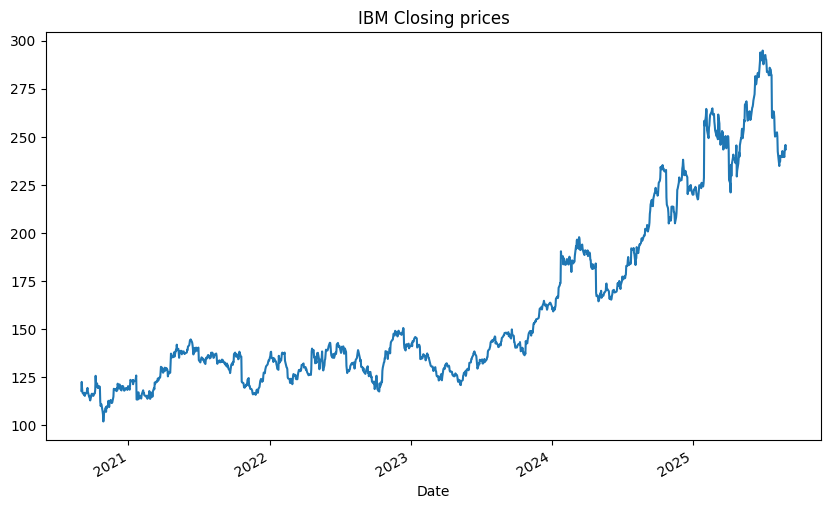

In [11]:
prices["Close"].plot(title="IBM Closing prices", figsize=(10,6))

Let's use YFinance again to retrieve the dividends paid by the company. This information (along with many other) is available through a YFinance `Ticker` object (`yf.Ticker`).

In [12]:
type(yf.Ticker(myTicker))

yfinance.ticker.Ticker

In [13]:
yf.Ticker(myTicker).info

{'address1': 'One New Orchard Road',
 'city': 'Armonk',
 'state': 'NY',
 'zip': '10504',
 'country': 'United States',
 'phone': '914 499 1900',
 'website': 'https://www.ibm.com',
 'industry': 'Information Technology Services',
 'industryKey': 'information-technology-services',
 'industryDisp': 'Information Technology Services',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': "International Business Machines Corporation, together with its subsidiaries, provides integrated solutions and services in the Americas, Europe, the Middle East, Africa, and the Asia Pacific. It operates through Software, Consulting, Infrastructure, and Financing segments. The Software segment offers hybrid cloud and AI platforms that allow clients to realize their digital and AI transformations across the applications, data, and environments in which they operate. The Consulting segment delivers strategy and technology services and intelligent operations, 

In [14]:
dividends = yf.Ticker(myTicker).dividends

In [15]:
dividends

,Dividends
Date,
1962-02-06 00:00:00-05:00,0.000956
1962-05-08 00:00:00-04:00,0.000956
1962-08-07 00:00:00-04:00,0.000956
1962-11-05 00:00:00-05:00,0.000956
1963-02-05 00:00:00-05:00,0.001275
...,...
2025-05-09 00:00:00-04:00,1.680000
2025-08-08 00:00:00-04:00,1.680000
2025-11-10 00:00:00-05:00,1.680000


Unfortunately, the timestamps in the index of the `prices` DataFrame are not directly comparable with those in the `dividends` series, as the latter also includes timezone information. Therefore, before making any comparisons, we remove this additional (and irrelevant) detail.

In [16]:
prices.index[0]

Timestamp('2020-09-01 00:00:00')

In [17]:
dividends.index[0]

Timestamp('1962-02-06 00:00:00-0500', tz='America/New_York')

In [18]:
dividends = dividends.tz_localize(None)

In [19]:
dividends.index[0]

Timestamp('1962-02-06 00:00:00')

In [20]:
dividends[myStart:myEnd]

,Dividends
Date,
2020-11-09,1.558317
2021-02-09,1.558317
2021-05-07,1.567878
2021-08-09,1.567878
2021-11-09,1.640000
2022-02-10,1.640000
2022-05-09,1.650000
2022-08-09,1.650000
2022-11-09,1.650000


In [21]:
len(dividends[myStart:myEnd])

20

In [22]:
len(prices)

1255

Now we add a new column named "Dividend" to the `prices` DataFrame, initialized with zeros, and populate it with the actual dividends paid by the company on the corresponding payout dates.

In [23]:
prices["Dividend"] = 0.0

for date in dividends.index:
  if date in prices.index:
    prices.at[date, "Dividend"] = dividends[date]

In [24]:
prices

Price,Adj Close,Close,Dividend
Date,,,
2020-09-01,93.322189,117.973228,0.0
2020-09-02,96.937119,122.543022,0.0
2020-09-03,94.116272,118.977058,0.0
2020-09-04,92.490311,116.921608,0.0
2020-09-08,91.665985,115.879539,0.0
...,...,...,...
2025-08-25,235.037292,239.429993,0.0
2025-08-26,238.178604,242.630005,0.0
2025-08-27,240.348038,244.839996,0.0


We can now rename the columns of the `prices` DataFrame using the usual shorter labels.

In [25]:
prices = prices.rename(columns={prices.columns[0]: "AP'", prices.columns[1]: "P", prices.columns[2]: "D"})
prices

Price,AP',P,D
Date,,,
2020-09-01,93.322189,117.973228,0.0
2020-09-02,96.937119,122.543022,0.0
2020-09-03,94.116272,118.977058,0.0
2020-09-04,92.490311,116.921608,0.0
2020-09-08,91.665985,115.879539,0.0
...,...,...,...
2025-08-25,235.037292,239.429993,0.0
2025-08-26,238.178604,242.630005,0.0
2025-08-27,240.348038,244.839996,0.0


Now that we have all the primary data sources, we can export the dataset to Excel to double-check the results of future computations, if needed.

In [26]:
prices.to_excel("myPrices.xlsx")

Now, we can compute the *forward* adjusted closing price, starting from the closing price and the dividend series. Recall that the forward version of the adjusted closing price, denoted by $\{ AP_t \}_{t \in \mathbb{N}}$, is defined as
$$
  AP_t = P_t \prod_{\tau = 0}^t \left( 1 + \frac{D_\tau}{P_\tau} \right),
$$
for any $t \in \mathbb{N}$, where $\{ P_t \}_{t \in \mathbb{N}}$ represents the closing price.

In [27]:
prices["AP"] = 0.0
adjustmentFactor = 1

for i in range(len(prices)):
  P = prices["P"].iloc[i]
  D = prices["D"].iloc[i]
  #adjustmentFactor = adjustmentFactor*(1+D/P)
  adjustmentFactor *= (1+D/P)
  prices.at[prices.index[i], "AP"] = P*adjustmentFactor

In [28]:
prices

Price,AP',P,D,AP
Date,,,,
2020-09-01,93.322189,117.973228,0.0,117.973228
2020-09-02,96.937119,122.543022,0.0,122.543022
2020-09-03,94.116272,118.977058,0.0,118.977058
2020-09-04,92.490311,116.921608,0.0,116.921608
2020-09-08,91.665985,115.879539,0.0,115.879539
...,...,...,...,...
2025-08-25,235.037292,239.429993,0.0,297.472592
2025-08-26,238.178604,242.630005,0.0,301.448351
2025-08-27,240.348038,244.839996,0.0,304.194088


Loops over pandas objects are generally quite slow. A more efficient way to achieve the same result is shown below.

In [29]:
# go to ChatGPT

We can now plot the series of closing prices and adjusted closing prices together on the same chart.

<Axes: xlabel='Date'>

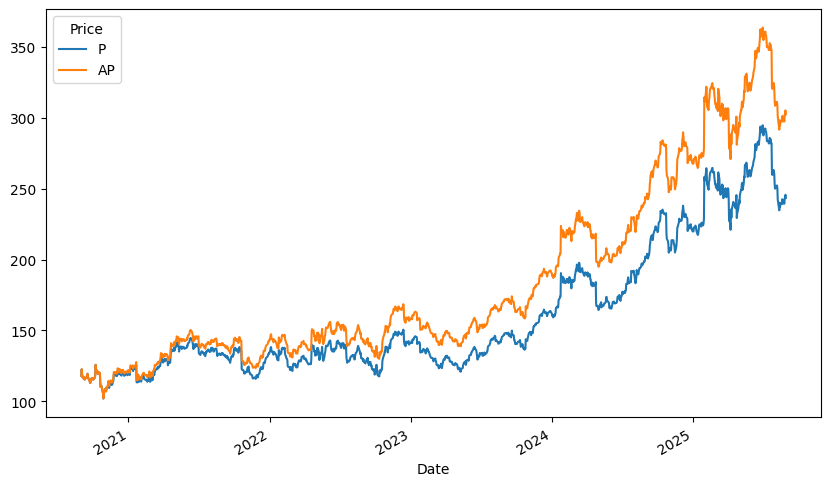

In [30]:
prices[["P","AP"]].plot(figsize=(10,6))

We can also mark the dividend payout dates by adding vertical black dashed lines, using the `dividends` series.

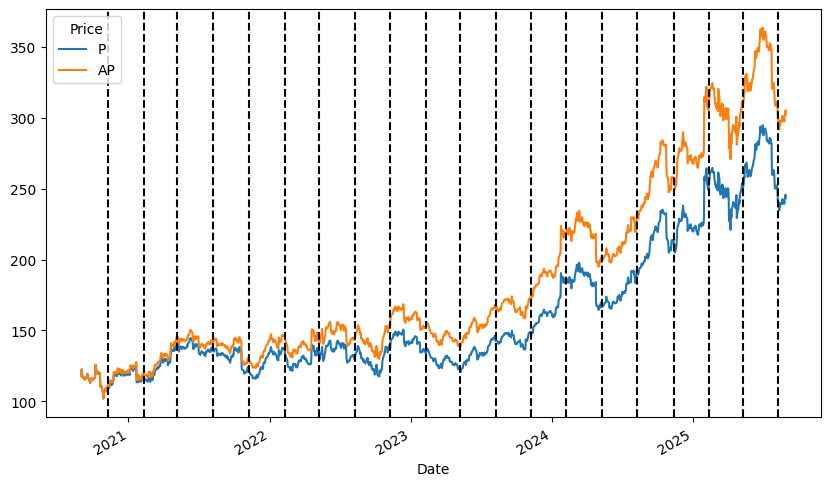

In [31]:
ax = prices[["P","AP"]].plot(figsize=(10,6))

for divPayDate in dividends[myStart:myEnd].index:
  ax.axvline(x = divPayDate, color = "black", linestyle = "--")

In [32]:
type(ax)

matplotlib.axes._axes.Axes

Let's now turn to returns. Specifically, we'll create a new DataFrame, `returns`, and populate it with the one-period linear and log returns of both the closing price series and the adjusted closing price series.

In [33]:
import pandas as pd

returns = pd.DataFrame()

In [35]:
import numpy as np

returns["rP"] = prices["P"]/prices["P"].shift(1)-1
returns["rAP"] = prices["AP"]/prices["AP"].shift(1)-1
returns["r*P"] = np.log(prices["P"]/prices["P"].shift(1))
returns["r*AP"] = np.log(prices["AP"]/prices["AP"].shift(1))

In [36]:
returns

,rP,rAP,r*P,r*AP
Date,,,,
2020-09-01,NaN,NaN,NaN,NaN
2020-09-02,0.038736,0.038736,0.038004,0.038004
2020-09-03,-0.029100,-0.029100,-0.029531,-0.029531
2020-09-04,-0.017276,-0.017276,-0.017427,-0.017427
2020-09-08,-0.008913,-0.008913,-0.008952,-0.008952
...,...,...,...,...
2025-08-25,-0.010988,-0.010988,-0.011048,-0.011048
2025-08-26,0.013365,0.013365,0.013277,0.013277
2025-08-27,0.009108,0.009108,0.009067,0.009067


Notice how the method `.shift(1)` works: it moves all values down by one row. Thus, each element is replaced by the value from the previous row, i.e., the value at time $t-1$.


In [37]:
testSeries = pd.Series([10, 20, 30, 40], index=pd.date_range(myStart, periods=4))
testSeries

,0
2020-09-01,10
2020-09-02,20
2020-09-03,30
2020-09-04,40


In [38]:
testSeries.shift(1)

,0
2020-09-01,NaN
2020-09-02,10.0
2020-09-03,20.0
2020-09-04,30.0


Let us also introduce the dividend yield, expressed in its "return formulation":
$$
\text{Dividend Yield}_t = \frac{D_t}{P_{t-1}} \, .
$$

In [39]:
returns["Div. Yield"] = prices["D"]/prices["P"].shift(1)
returns

,rP,rAP,r*P,r*AP,Div. Yield
Date,,,,,
2020-09-01,NaN,NaN,NaN,NaN,NaN
2020-09-02,0.038736,0.038736,0.038004,0.038004,0.0
2020-09-03,-0.029100,-0.029100,-0.029531,-0.029531,0.0
2020-09-04,-0.017276,-0.017276,-0.017427,-0.017427,0.0
2020-09-08,-0.008913,-0.008913,-0.008952,-0.008952,0.0
...,...,...,...,...,...
2025-08-25,-0.010988,-0.010988,-0.011048,-0.011048,0.0
2025-08-26,0.013365,0.013365,0.013277,0.013277,0.0
2025-08-27,0.009108,0.009108,0.009067,0.009067,0.0


When computing returns, the first data point is always lost and typically replaced with a `NaN`. Since having `NaN` values inside a DataFrame can be problematic, we drop all rows that contain at least one `NaN`.

In [40]:
returns = returns.dropna()
returns

,rP,rAP,r*P,r*AP,Div. Yield
Date,,,,,
2020-09-02,0.038736,0.038736,0.038004,0.038004,0.0
2020-09-03,-0.029100,-0.029100,-0.029531,-0.029531,0.0
2020-09-04,-0.017276,-0.017276,-0.017427,-0.017427,0.0
2020-09-08,-0.008913,-0.008913,-0.008952,-0.008952,0.0
2020-09-09,0.008663,0.008663,0.008625,0.008625,0.0
...,...,...,...,...,...
2025-08-25,-0.010988,-0.010988,-0.011048,-0.011048,0.0
2025-08-26,0.013365,0.013365,0.013277,0.013277,0.0
2025-08-27,0.009108,0.009108,0.009067,0.009067,0.0


Let's verify a couple of properties that we know should hold from theory. In particular, we'll check that one-period linear returns are always greater than or equal to the corresponding one-period log returns…

In [41]:
returns["rP"] >= returns["r*P"]

,0
Date,
2020-09-02,True
2020-09-03,True
2020-09-04,True
2020-09-08,True
2020-09-09,True
...,...
2025-08-25,True
2025-08-26,True
2025-08-27,True


In [42]:
sum( returns["rP"] >= returns["r*P"] )

1254

In [43]:
len( returns["rP"] >= returns["r*P"] )

1254

In [44]:
sum( returns["rP"] >= returns["r*P"] ) == len( returns["rP"] >= returns["r*P"] )

True

…and that one-period linear returns computed from adjusted closing prices are always greater than or equal to those computed from closing prices alone.

The result of this last check may seem puzzling, but it is in fact only due to minor numerical imprecision.

Let us now examine the summary statistics of both the returns and the dividend yield.

In [45]:
stats = returns.describe()
stats

,rP,rAP,r*P,r*AP,Div. Yield
count,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000
mean,0.000692,0.000864,0.000578,0.000751,0.000171
std,0.015117,0.014984,0.015132,0.014996,0.001377
min,-0.099050,-0.099050,-0.104306,-0.104306,0.000000
25%,-0.006609,-0.006486,-0.006631,-0.006507,0.000000
50%,0.001006,0.001030,0.001006,0.001030,0.000000
75%,0.008090,0.008115,0.008058,0.008082,0.000000
max,0.129642,0.129642,0.121901,0.121901,0.014293


The autocorrelation statistic is not directly provided. However, it can be computed for any single DataFrame column at an arbitrary lag $k$. Recall that the autocorrelation at lag $k$ of a series $\{X_t\}_{t \in \mathbb{N}}$ is defined as $\text{corr} \left[ X_t, X_{t-k} \right]$.

In [46]:
returns["r*P"].autocorr(lag = 1)

np.float64(0.009254493710728237)

Alternatively, we can take a more direct approach by computing the sample correlation with NumPy's `corrcoef` function. This function returns the full correlation matrix, from which we extract the relevant coefficient, by correlating the first $n-1$ entries of the series (omitting the last one) with the last $n-1$ entries (omitting the first one).

In [47]:
np.corrcoef(returns["r*P"].iloc[1:], returns["r*P"].iloc[:-1])[0,1]

np.float64(0.009254493710728237)

From theory we know that
$$
r_t^{AP} = r_t^{P} + \frac{D_t}{P_{t-1}}
$$
(see Equation (1.37) of the Lecture Notes, where it is expressed in normalized terms of the Price Index (PI) and the Total Return Index (RI)).

But what about the relationship between
$$
\text{V}\!\left[r_t^{AP}\right]
\quad \text{and} \quad
\text{V}\!\left[r_t^{P}\right] + \text{V}\!\left[\frac{D_t}{P_{t-1}}\right] \, ?
$$
Since we are working with linear returns, we can also express their daily standard deviations in percentage terms, for the sake of readability.

In [48]:
sigma_rAP = stats["rAP"].loc["std"]*100
sigma_rP = stats["rP"].loc["std"]*100
sigma_DivYield = stats["Div. Yield"].loc["std"]*100

In [49]:
sigma_rAP**2 >= sigma_rP**2 +sigma_DivYield**2

np.False_

In [50]:
sigma_rAP**2 < sigma_rP**2 +sigma_DivYield**2

np.True_

In [51]:
np.corrcoef(returns["rP"], returns["Div. Yield"])[0,1]

np.float64(-0.14158047941202834)

In [52]:
cov_rP_divYield = 0.5*(sigma_rAP**2 -sigma_rP**2 -sigma_DivYield**2)
cov_rP_divYield

np.float64(-0.029471615753191547)

In [53]:
corr_rP_divYield = cov_rP_divYield/(sigma_rP*sigma_DivYield)
corr_rP_divYield

np.float64(-0.14158047941203727)

Therefore, there appears to be a (small) negative correlation between the growth rate of prices and the dividend yield. This is even more surprising then the (only) mild positive correlation observed between the same variables in Shiller's dataset.  

We now proceed to estimate this correlation coefficient.

Returns can be aggregated over time using the built-in `resample` method of pandas DataFrames. This method groups the data into the desired time frequency (e.g., monthly, quarterly) and then applies an aggregation function such as `sum`, `mean`, or `prod` within each group.

In [54]:
returns_M = pd.DataFrame()

returns_M["rP"] = (1 + returns["rP"]).resample("ME").prod()-1

In [55]:
returns_M

,rP
Date,
2020-09-30,-0.014019
2020-10-31,-0.082272
2020-11-30,0.106215
2020-12-31,0.019106
2021-01-31,-0.053781
2021-02-28,-0.001511
2021-03-31,0.120491
2021-04-30,0.064686
2021-05-31,0.013110
